In [1]:
import os
import sys

import collections
import xarray as xr
xr.set_options(keep_attrs=True)
import netCDF4 as nc
import numpy as np
np.seterr(divide='ignore', invalid='ignore')
import metpy.calc as mp
from metpy.units import units
from scipy.stats import ttest_ind, ttest_rel
from datetime import datetime

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.geometry.polygon import LinearRing

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm
from matplotlib import cm
from matplotlib.colors import ListedColormap,LinearSegmentedColormap
import cmocean.cm as cmo

# settings
%config InlineBackend.figure_format = 'retina'

In [22]:
### +++ LOAD DATA +++ ###

# set file info
dpath0='../topo_files' # top level data directory
files={ 'ctrl':{}, 'max':{}, 'p85':{}, 'p80':{}, '1.5env':{}, '1env':{} }

files['ctrl'] = f'{dpath0}/e2pt1.ctrl.zsurf.nc'
files['max'] = f'{dpath0}/e2pt1.max.global.zsurf.nc'
files['p85'] = f'{dpath0}/e2pt1.85p.ca-sa.zsurf.nc'
files['p80'] = f'{dpath0}/e2pt1.80p.ca-sa.zsurf.nc'
files['1.5env'] = f'{dpath0}/e2pt1.1pt5sEnv.ca-sa.zsurf.nc'
files['1env'] = f'{dpath0}/e2pt1.1sEnv.ca-sa.zsurf.nc'

# read in land mask from default surface boundary condition file
land_mask = xr.open_dataset(files[key]).fgrnd

# init dictionaries
topo={ 'ctrl':{}, 'max':{}, 'p85':{}, 'p80':{}, '1.5env':{}, '1env':{} }
diff={ 'max':{}, 'p85':{}, 'p80':{}, '1.5env':{}, '1env':{} }

for key in files.keys():
    # grab surface height data from cells with land area
    topo[key] = xr.open_dataset(files[key]).zatmo.where(land_mask>0.1) 
    
    # calculate the change in surface height between modified BCs and control BC
    if key=='ctrl':
        pass
    else:
        diff[key]=topo[key]-topo['ctrl']
        

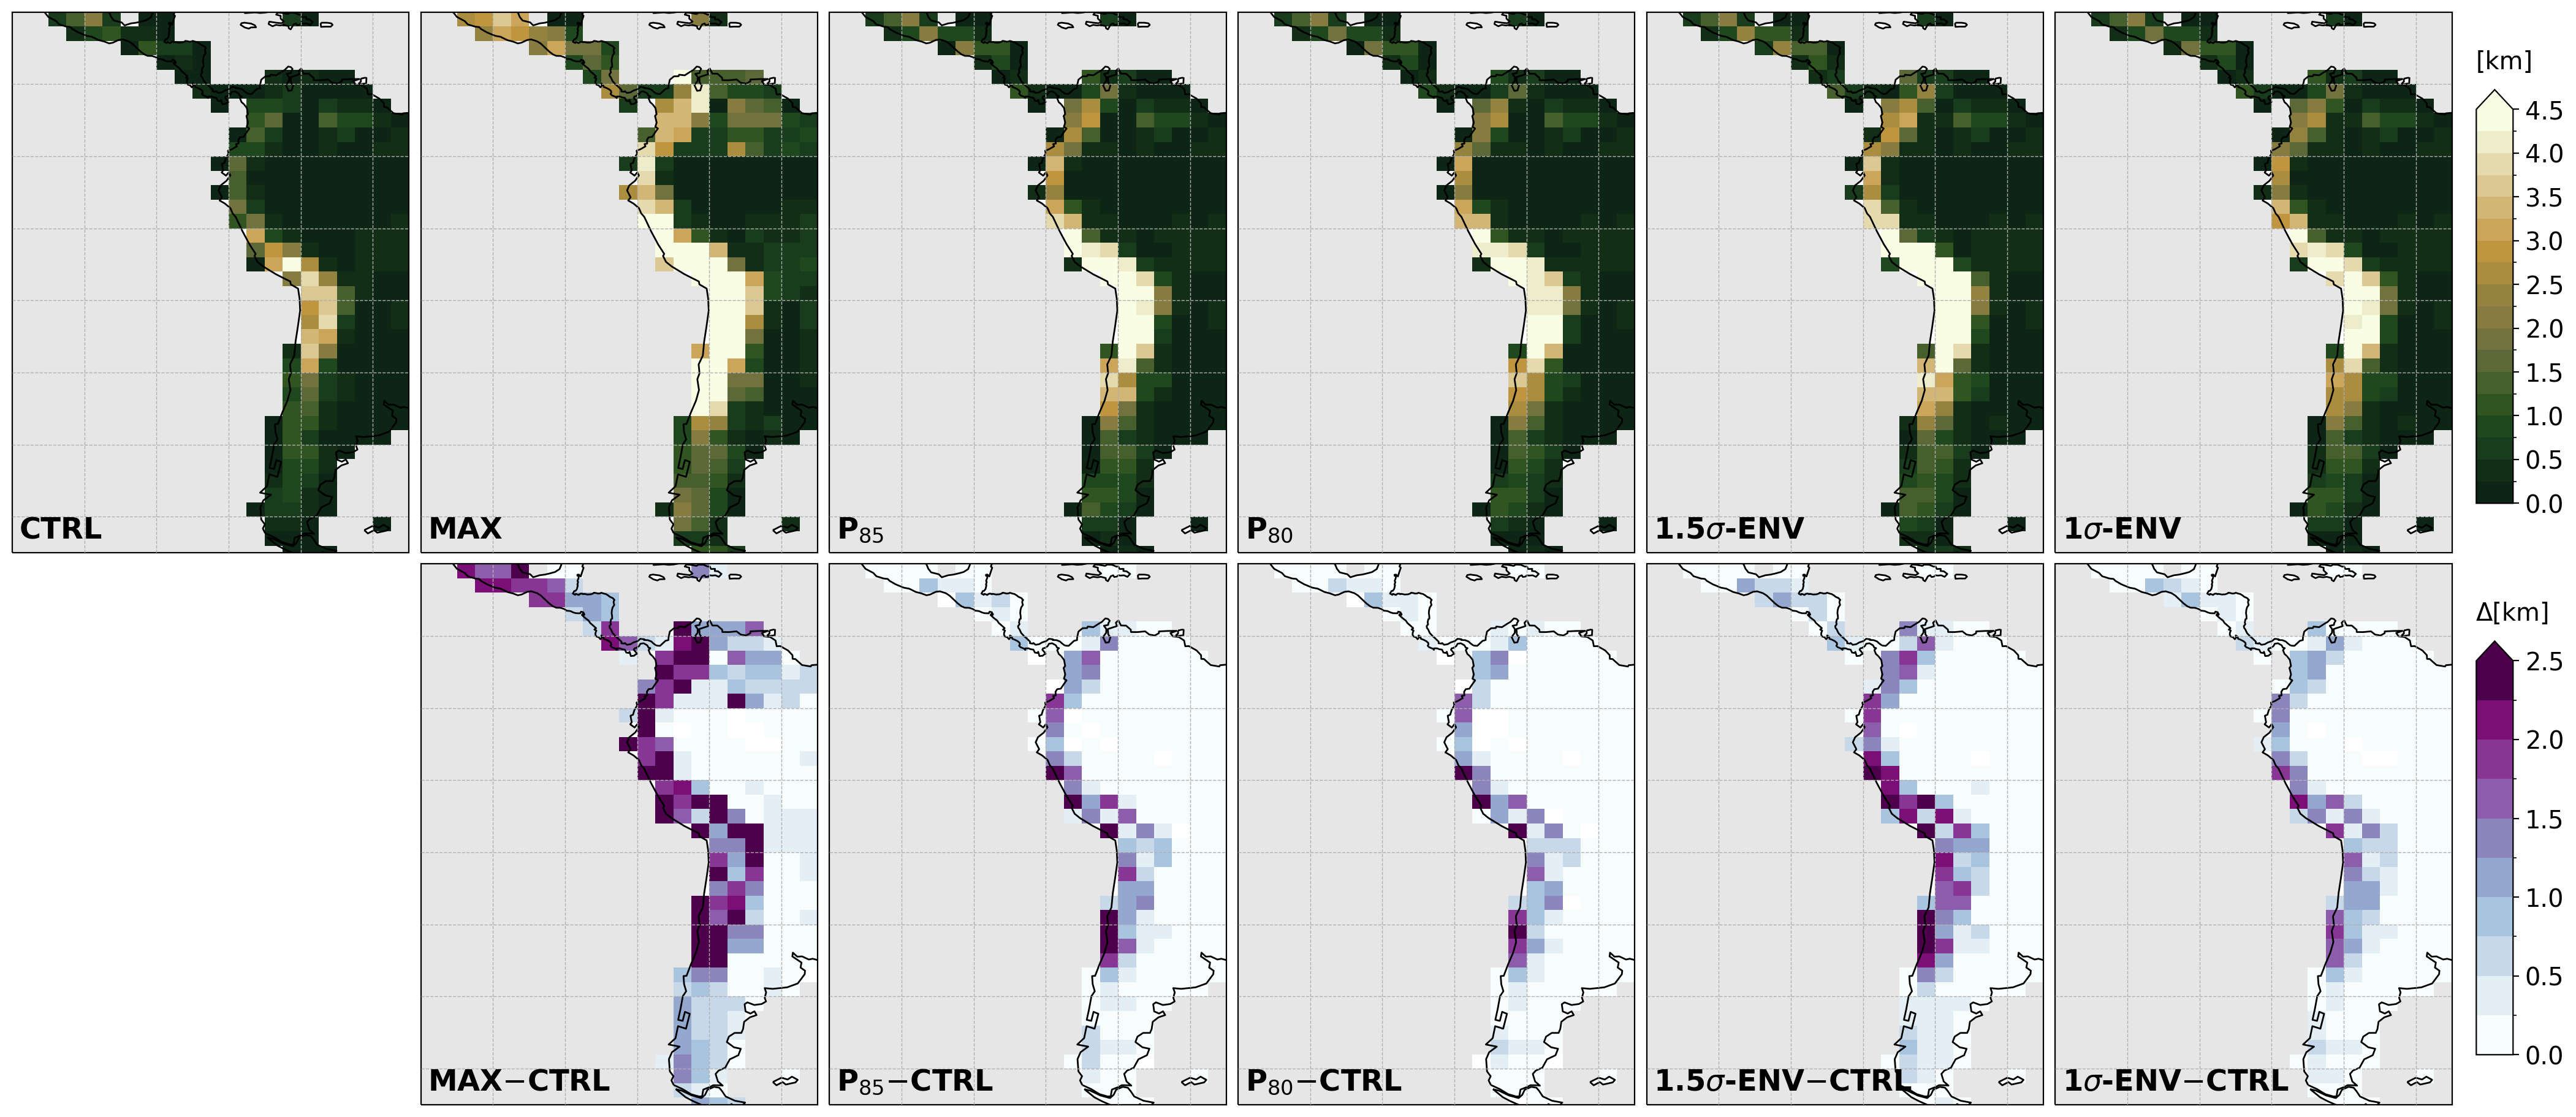

In [40]:
# text specs
titles=np.array(['CTRL', 'MAX', 'P$_{85}$', 'P$_{80}$', '1.5$\sigma$-ENV', '1$\sigma$-ENV'])
font={'color':  'k', 'weight': 'bold', 'size': 'xx-large', 'horizontalalignment': 'left'}
# base colormap
cmap_full=cmo.topo
cmap=ListedColormap(cmap_full(np.linspace(0.5, 1)))
vmin=0
vmax=4.5
levels=np.linspace(vmin,vmax,19)
norm=mpl.colors.BoundaryNorm(levels, cmap.N)
# difference colormap
dcmap=cm.BuPu
dcmap.set_under('white', 1.0)
dvmin=0.
dvmax=2.5
dlevels=np.linspace(dvmin,dvmax,11)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# map specs
lon=topo['ctrl'].lon
lat=topo['ctrl'].lat
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds = [-110., -55., -55., 20.]


fig=plt.figure(figsize=(20,9), layout='constrained')

for i,key in enumerate(topo.keys()):
    ax=plt.subplot2grid((2, 6), (0, i), colspan=1, rowspan=1, projection=proj)
    ax.text(-109, -53, titles[i], fontdict=font, zorder=100)
    cf=ax.pcolormesh(lon, lat, topo[key]/1000, cmap=cmap, norm=norm, transform=trans, zorder=2)
    ax.coastlines(zorder=3)
    ax.add_feature(cfeature.OCEAN, fc=(0.9, 0.9, 0.9), zorder=1)
    ax.set_extent(map_bnds, crs=trans)
    ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=False)

for i,key in enumerate(topo.keys()):
    if i==0:
        ax=plt.subplot2grid((2, 6), (1, i), colspan=1, rowspan=1, projection=proj)
        ax.set_visible(False)
    else:
        ax=plt.subplot2grid((2, 6), (1, i), colspan=1, rowspan=1, projection=proj)
        ax.text(-109, -53, titles[i]+'$-$CTRL', fontdict=font, zorder=100)
        cf2=ax.pcolormesh(lon, lat, diff[key]/1000, cmap=dcmap, norm=dnorm, transform=trans, zorder=2)
        ax.coastlines(zorder=3)
        ax.add_feature(cfeature.OCEAN, fc=(0.9, 0.9, 0.9), zorder=1)
        ax.set_extent(map_bnds, crs=trans)
        ax.gridlines(crs=trans, lw=.5, colors='black', alpha=1.0, linestyle='--', zorder=10, draw_labels=False)

## Colorbars
# field
cax=fig.add_axes([1.0075, 0.55, 0.015, 0.375])
cbar=fig.colorbar(cf, orientation='vertical', extend='max', cax=cax)
cbar.set_label('[km]', y=1.15, labelpad=-30, rotation=0, size='x-large', ha='center')
cbar.ax.tick_params(labelsize='x-large')
# diff
cax2=fig.add_axes([1.0075, 0.05, 0.015, 0.375])
cbar2=fig.colorbar(cf2, orientation='vertical', extend='max', cax=cax2)
cbar2.set_label('Δ[km]', y=1.15, labelpad=-30, rotation=0, size='x-large', ha='center')
cbar2.ax.tick_params(labelsize='x-large')
